In [ ]:
# Confirm you're actually on a GPU runtime first: Runtime -> Change runtime type -> T4 GPU
!pip install paddleocr ipywidgets requests pillow matplotlib -q
!python -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/ -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/

In [ ]:
!pip install -q nvidia-nccl-cu12==2.28.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
paddlepaddle-gpu 3.2.0 requires nvidia-nccl-cu12==2.25.1; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-nccl-cu12 2.28.9 which is incompatible.
torch 2.11.0+cu128 requires nvidia-cudnn-cu12==9.19.0.56; platform_system == "Linux", but you have nvidia-cudnn-cu12 9.5.1.17 which is incompatible.
torch 2.11.0+cu128 requires nvidia-cusparselt-cu12==0.7.1; platform_system == "Linux", but you have nvidia-cusparselt-cu12 0.6.3 which is incompatible.


In [ ]:
import paddle
print("GPU available to Paddle:", paddle.device.is_compiled_with_cuda())
print("Device count:", paddle.device.cuda.device_count() if paddle.device.is_compiled_with_cuda() else 0)

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


GPU available to Paddle: True
Device count: 1


In [ ]:
import json
import io

import requests
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR

print("Imports OK.")

Imports OK.


In [ ]:
# enable_mkldnn=False avoids the NotImplementedError:
# "ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]"
# which happens on some CPUs (including Colab's) when oneDNN is on by default.
ocr = PaddleOCR(use_angle_cls=True, lang="en", enable_mkldnn=False)
print("PaddleOCR ready.")

/tmp/ipykernel_7026/2170804150.py:4: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang="en", enable_mkldnn=False)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

PaddleOCR ready.


In [ ]:
import time

t0 = time.time()
result = ocr.predict("/content/WhatsApp Image 2026-09-21 at 7.54.25 PM.jpeg")[0]
print(f"Run 1: {time.time() - t0:.1f}s")

t0 = time.time()
result = ocr.predict("/content/WhatsApp Image 2026-09-21 at 7.54.25 PM.jpeg")[0]  # same image again, or swap IMAGE_PATH for a second upload
print(f"Run 2: {time.time() - t0:.1f}s")

Run 1: 3.0s
Run 2: 0.7s


Saving Screenshot 2026-09-22 005856.png to Screenshot 2026-09-22 005856.png


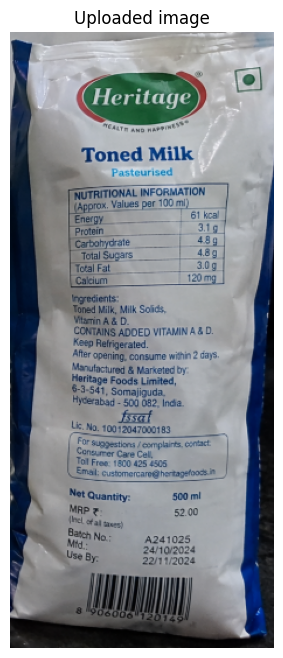

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

IMAGE_PATH = next(iter(uploaded.keys()))

img = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded image")
MAX_DIM = 1800
if max(img.size) > MAX_DIM:
    ratio = MAX_DIM / max(img.size)
    img = img.resize((int(img.width * ratio), int(img.height * ratio)))
    img.save(IMAGE_PATH)  # so ocr.predict() reads the resized version too
plt.show()

In [ ]:
result = ocr.predict(IMAGE_PATH)[0]

texts = result["rec_texts"]
scores = result["rec_scores"]
boxes = result["rec_boxes"]

print(f"Detected {len(texts)} text lines:\n")

for t, s, b in zip(texts, scores, boxes):
    print(f"[{s:.2f}] {t!r} bbox={list(b)}")

Detected 45 text lines:

[1.00] 'Heritage' bbox=[np.int16(53), np.int16(22), np.int16(158), np.int16(58)]
[0.95] 'HEALTH AND HAPPINESSO' bbox=[np.int16(66), np.int16(62), np.int16(152), np.int16(82)]
[1.00] 'Toned Milk' bbox=[np.int16(47), np.int16(85), np.int16(157), np.int16(109)]
[1.00] 'Pasteurised' bbox=[np.int16(78), np.int16(108), np.int16(136), np.int16(119)]
[0.99] 'NUTRITIONAL INFORMATION' bbox=[np.int16(38), np.int16(117), np.int16(169), np.int16(140)]
[0.95] '(Approx. Values per 100 mi)' bbox=[np.int16(39), np.int16(129), np.int16(153), np.int16(150)]
[1.00] 'Energy' bbox=[np.int16(39), np.int16(146), np.int16(74), np.int16(161)]
[0.99] '61 kcal' bbox=[np.int16(150), np.int16(140), np.int16(184), np.int16(155)]
[1.00] 'Protein' bbox=[np.int16(38), np.int16(154), np.int16(75), np.int16(172)]
[1.00] '3.1g' bbox=[np.int16(159), np.int16(153), np.int16(185), np.int16(165)]
[1.00] 'Carbohydrate' bbox=[np.int16(39), np.int16(164), np.int16(98), np.int16(183)]
[0.96] '4.8g' bbox=[

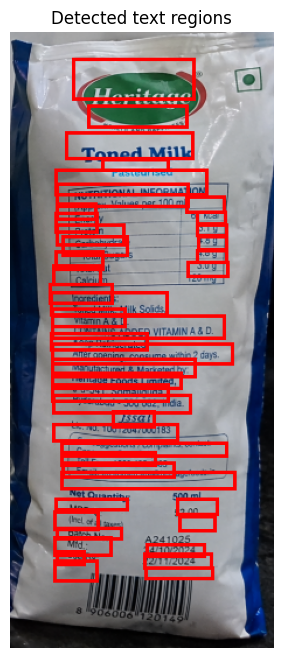

In [ ]:
annotated = img.copy()
draw = ImageDraw.Draw(annotated)
for b in boxes:
    x_min, y_min, x_max, y_max = b
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)

plt.figure(figsize=(6, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Detected text regions")
plt.show()

In [ ]:
def reconstruct_rows(fields: list[dict], tolerance_ratio: float = 0.5) -> list[list[dict]]:
    if not fields:
        return []
    heights = [f["bbox"][3] - f["bbox"][1] for f in fields]
    median_h = sorted(heights)[len(heights) // 2]
    y_tolerance = median_h * tolerance_ratio

    items = sorted(fields, key=lambda f: (f["bbox"][1] + f["bbox"][3]) / 2)
    rows: list[list[dict]] = []
    for item in items:
        y_center = (item["bbox"][1] + item["bbox"][3]) / 2
        placed = False
        for row in rows:
            row_y = sum((r["bbox"][1] + r["bbox"][3]) / 2 for r in row) / len(row)
            if abs(y_center - row_y) <= y_tolerance:
                row.append(item)
                placed = True
                break
        if not placed:
            rows.append([item])
    return [sorted(row, key=lambda f: f["bbox"][0]) for row in rows]

In [ ]:
import re
def find_value_near_label(rows: list[list[dict]], label_box: dict, value_pattern: re.Pattern,
                            max_row_lookahead: int = 2) -> str | None:
    """Search same-row-to-the-right first, then subsequent rows, for a box
    whose text matches value_pattern. Geometric, not text-order dependent."""
    label_row_idx = next(i for i, row in enumerate(rows) if label_box in row)
    label_x_end = label_box["bbox"][2]

    # same row, to the right of the label
    same_row_candidates = [f for f in rows[label_row_idx] if f["bbox"][0] >= label_x_end]
    for f in sorted(same_row_candidates, key=lambda f: f["bbox"][0]):
        m = value_pattern.search(f["text"])
        if m:
            return m.group(1) if m.groups() else m.group(0)

    # next N rows down, closest x to the label first
    for row in rows[label_row_idx + 1: label_row_idx + 1 + max_row_lookahead]:
        for f in sorted(row, key=lambda f: abs(f["bbox"][0] - label_box["bbox"][0])):
            m = value_pattern.search(f["text"])
            if m:
                return m.group(1) if m.groups() else m.group(0)
    return None

In [ ]:
PX_TO_MM_SCALE = 0.264

fields = []
for text, score, box in zip(texts, scores, boxes):
    if score < 0.5:
        continue
    x_min, y_min, x_max, y_max = box
    pixel_height = y_max - y_min
    fields.append({
        "text": text,
        "font_height_mm": round(float(pixel_height) * PX_TO_MM_SCALE, 2),
        "ocr_confidence": round(float(score), 3),
        "bbox": [float(x_min), float(y_min), float(x_max), float(y_max)],
    })

rows = reconstruct_rows(fields)                      # list[list[dict]] — geometric structure
raw_ocr_text = "\n".join(" ".join(f["text"] for f in row) for row in rows)  # flattened, for display/logging only

validation_request = {
    "image_id": "notebook-test-001",
    "raw_ocr_text": raw_ocr_text,
    "mean_ocr_confidence": round(sum(f["ocr_confidence"] for f in fields) / len(fields), 3) if fields else None,
    "px_to_mm_scale_factor": PX_TO_MM_SCALE,
    "fields": fields,
}

print(json.dumps(validation_request, indent=2))

{
  "image_id": "notebook-test-001",
  "raw_ocr_text": "Heritage\nHEALTH AND HAPPINESSO\nToned Milk\nPasteurised\nNUTRITIONAL INFORMATION\n(Approx. Values per 100 mi) 61 kcal\nProtein Energy 3.1g\nCarbohydrate 4.8g\nTotal Sugars 4.8 g\nTotal Fat 3.0g\nCalcium 120 mg\nIngredients:\nToned Milk, Milk Solids.\nVitamin A & D. CONTAINS ADDED VITAMIN A & D.\nKeep Refrigerated.\nAfter opening, consume within 2 days.\nManufactured & Marketed by:\nHeritage Foods Limited,\n6-3-541, Somajiguda.\nHyderabad - 500 082, India.\nfssal\nLic. No. 10012047000183\nFor suggestions /complaints, contact Consumer Care Cell\nToll Free: 1800 425 4505\nEmail: customercare@heritagefoods.in\nNet Quantity: 500 ml\nMRP 52.00\n(Incl, of all taxes)\nBatch No.: A241025\nMfd.: 24/10/2024\nUse By: 22/11/2024",
  "mean_ocr_confidence": 0.981,
  "px_to_mm_scale_factor": 0.264,
  "fields": [
    {
      "text": "Heritage",
      "font_height_mm": 9.5,
      "ocr_confidence": 1.0,
      "bbox": [
        53.0,
        22.0,
 

In [ ]:
VALIDATION_ENGINE_URL = "http://127.0.0.1:8000/docs#/default/validate_validate_post"

try:
    response = requests.post(VALIDATION_ENGINE_URL, json=validation_request, timeout=10)
    response.raise_for_status()
    result_json = response.json()
    print(json.dumps(result_json, indent=2))
    print(f"\n>>> OVERALL VERDICT: {result_json.get('overall_verdict')}"
          f"  (score={result_json.get('compliance_score')})")
except requests.exceptions.ConnectionError:
    print("Couldn't reach the validation engine — see note below about localhost in Colab.")
except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")

Couldn't reach the validation engine — see note below about localhost in Colab.
